# Proyecto Final - Data Science & Machine Learning
## Predicción de Supervivencia en el Titanic 🚢

**Autor:** Lorena Goberna Milego
**Dataset:** Titanic - Machine Learning from Disaster (Kaggle)
**Objetivo:** Predecir si un pasajero sobrevivió o no basándonos en sus características (edad, sexo, clase, tarifa, etc.)

---

## 1. Carga de librerías

In [1]:
# Librerías para manipulación y análisis de datos
import pandas as pd
import numpy as np
import os
import joblib

# Librerías para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
print(os.getcwd())

C:\Users\nuc\PycharmProjects\Data_Project-main02\notebook


In [3]:
os.listdir()

['.ipynb_checkpoints', 'data', 'EDA-y-modelo.ipynb', 'models']

In [4]:
os.listdir("data")

['train.csv']

In [5]:
print(os.getcwd())
print(os.listdir("data"))

C:\Users\nuc\PycharmProjects\Data_Project-main02\notebook
['train.csv']


In [6]:
print(os.path.getsize("data/train.csv"))

57910


## 2. Carga del dataset

El dataset del Titanic contiene información sobre 891 pasajeros, incluyendo si sobrevivieron o no, su edad, sexo, clase, tarifa pagada y otros datos.

**Fuente:** Kaggle (cargado desde seaborn)

In [7]:
# Cargar dataset desde seaborn y guardarlo en data/
df = sns.load_dataset("titanic")
df.to_csv("data/train.csv", index=False)

print("Dataset guardado en data/train.csv")
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

Dataset guardado en data/train.csv
Dimensiones: 891 filas × 15 columnas


## 3. Análisis Exploratorio de Datos (EDA)

### 3.1 Inspección inicial

Mostramos las primeras filas, dimensiones, tipos de datos y estadísticas descriptivas para entender la estructura del dataset antes de cualquier modificación.

In [8]:
# Primeras filas del dataset
df = pd.read_csv("data/train.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Interpretación: La edad media es ~30 años. El 50% de los pasajeros pagó menos de 14.45 de tarifa (mediana), pero hay valores extremos (máximo 512.33). La media de survived (0.38) indica que solo el 38% sobrevivió → dataset desbalanceado.

### 3.3 Análisis de valores nulos

Identificamos qué columnas tienen datos faltantes y en qué proporción.

In [9]:
# Valores nulos por columna (cantidad)
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


Observación:
* age tiene 177 nulos (19.9%),
* deck tiene 688 nulos (77.2%),
* embarked y embark_town tienen 2 nulos cada una.

In [10]:
# Porcentaje de valores nulos por columna
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent_sorted = null_percent[null_percent > 0].sort_values(ascending=False)
print("Porcentaje de valores nulos por columna:")
print(null_percent_sorted)

Porcentaje de valores nulos por columna:
deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
dtype: float64


### 3.4 Detección y eliminación de duplicados:

In [11]:
# Detectar y eliminar filas duplicadas
print(f"Filas duplicadas antes de eliminar: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Dimensiones tras eliminar duplicados: {df.shape[0]} filas × {df.shape[1]} columnas")
print("No se encontraron duplicados significativos")

Filas duplicadas antes de eliminar: 107
Dimensiones tras eliminar duplicados: 784 filas × 15 columnas
No se encontraron duplicados significativos


### 3.5 Visualización de valores nulos

Gráfico de barras para visualizar el porcentaje de nulos por columna.

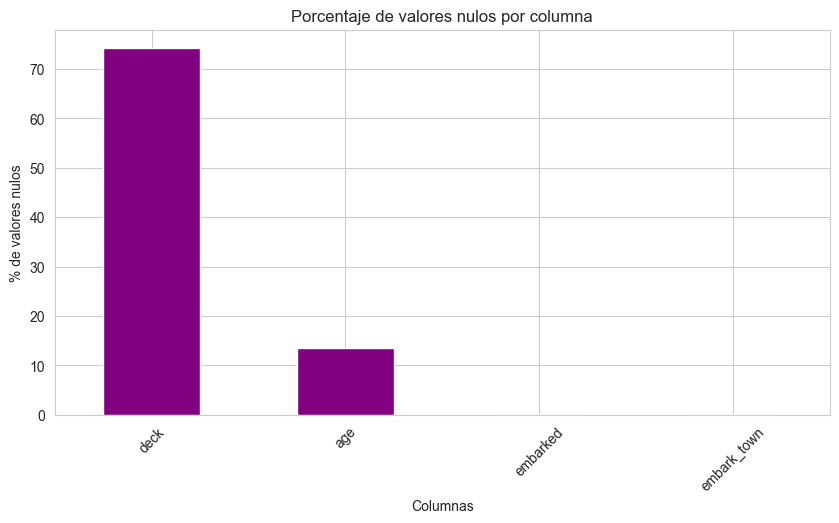

In [12]:
# Gráfico de barras con porcentaje de nulos por columna
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent = null_percent[null_percent > 0].sort_values(ascending=False)

null_percent.plot(kind='bar', color='purple', figsize=(10,5))
plt.title('Porcentaje de valores nulos por columna')
plt.ylabel('% de valores nulos')
plt.xlabel('Columnas')
plt.xticks(rotation=45)
plt.show()

Interpretación:
* deck supera el 75% de nulos → se eliminará la columna.
* age (~20%) → se imputará con la mediana.
* embarked y embark_town (<1%) → se imputarán con la moda.

### 3.4 Detección y eliminación de duplicados

In [13]:
# Detectar y eliminar filas duplicadas
print(f"Filas duplicadas antes de eliminar: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Dimensiones tras eliminar duplicados: {df.shape[0]} filas × {df.shape[1]} columnas")
print("No se encontraron duplicados significativos")

Filas duplicadas antes de eliminar: 0
Dimensiones tras eliminar duplicados: 784 filas × 15 columnas
No se encontraron duplicados significativos


### 3.5 Visualización de valores nulos

Gráfico de barras para visualizar el porcentaje de nulos por columna.

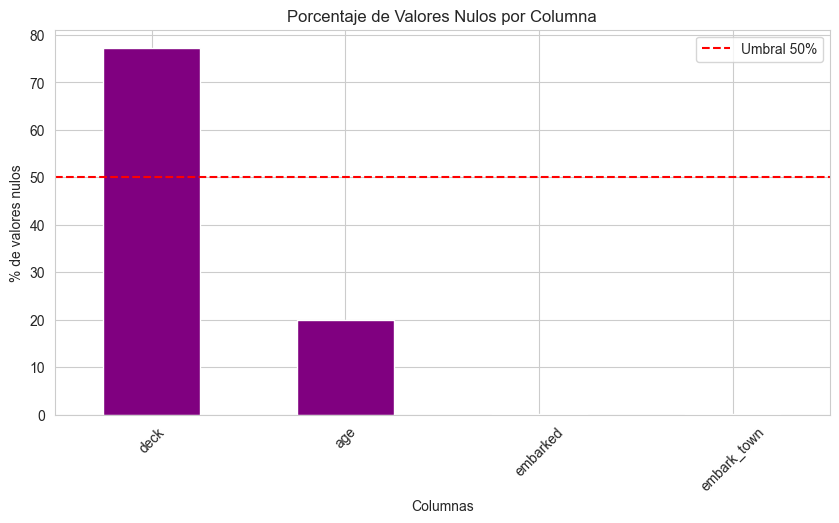

In [14]:
# Gráfico de barras: porcentaje de nulos por columna
null_percent_sorted.plot(kind='bar', color='purple', figsize=(10, 5))
plt.title('Porcentaje de Valores Nulos por Columna')
plt.ylabel('% de valores nulos')
plt.xlabel('Columnas')
plt.xticks(rotation=45)
plt.axhline(y=50, color='red', linestyle='--', label='Umbral 50%')
plt.legend()
plt.show()

Interpretación: 
* deck supera el 75% de nulos → se eliminará la columna.
* age (~20%) → se imputará con la mediana.
* embarked y embark_town (<1%) → se imputarán con la moda.

### 3.6 Matriz de correlación

Analizamos la relación lineal entre las variables numéricas y la variable objetivo.

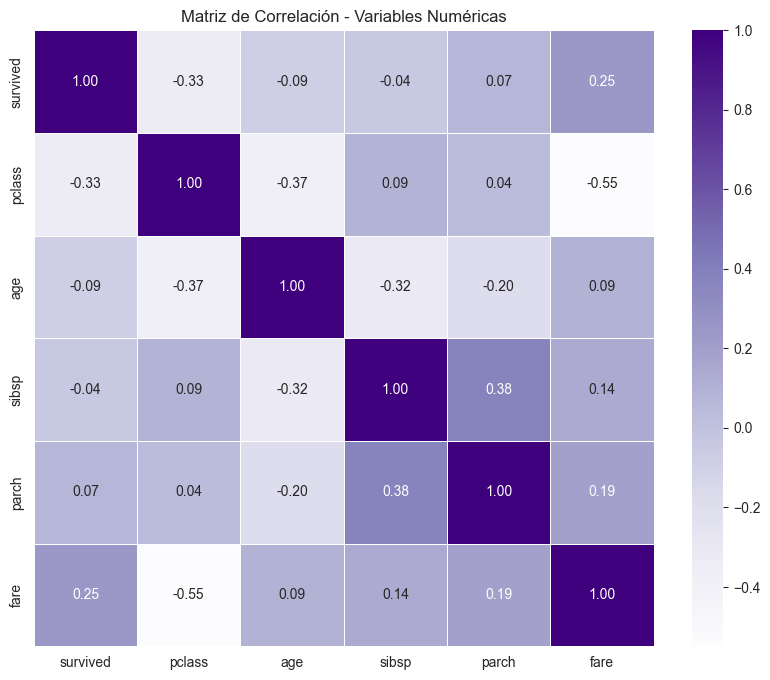

Correlación con 'survived':
survived    1.000000
fare        0.246769
parch       0.070307
sibsp      -0.036589
age        -0.086548
pclass     -0.332658
Name: survived, dtype: float64


In [15]:
# Seleccionar solo columnas numéricas
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Heatmap de correlación
plt.figure(figsize=(10,8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='Purples', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

# Correlación con la variable objetivo 'survived' 
print("Correlación con 'survived':")
print(df_numeric.corr()['survived'].sort_values(ascending=False))

Interpretación: Las variables más correlacionadas con survived son:
* pclass (-0.34, correlación negativa: a mayor clase numérica, menor supervivencia) y fare (0.26, correlación positiva: a mayor tarifa, mayor probabilidad de sobrevivir).
* age tiene correlación débil (-0.07).

---

## 4. Limpieza y preprocesamiento de datos

Aplicamos las estrategias identificadas en el EDA para dejar los datos listos para el modelo.

### 4.1 Eliminación de columnas con exceso de nulos

In [16]:
# Eliminar columna 'deck' (>75% de valores nulos)
# También eliminamos columnas que filtran información del target (data leakage)
columnas_a_eliminar = ['deck', 'alive', 'class', 'who', 'adult_male', 'alone', 'embark_town']

df_clean = df.drop(columnas_a_eliminar, axis=1)
print(f"Columnas eliminadas: {columnas_a_eliminar}")
print(f"Columnas restantes: {df_clean.columns.tolist()}")
print(f"Nuevas dimensiones: {df_clean.shape}")

Columnas eliminadas: ['deck', 'alive', 'class', 'who', 'adult_male', 'alone', 'embark_town']
Columnas restantes: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Nuevas dimensiones: (784, 8)


Justificación: 
* deck tiene >75% nulos, no aporta información útil.
* alive, who, adult_male, alone, embark_town, class son redundantes con survived, sex y embarked respectivamente, y pueden causar fuga de información (data leakage).

### 4.2 Tratamiento de valores nulos restantes

In [17]:
# Crear una COPIA independiente del DataFrame tras eliminar columnas
# Esto evita el error de Copy-on-Write y asegura que las modificaciones se apliquen correctamente
df_clean = df.drop(columnas_a_eliminar, axis=1).copy()

# Imputar 'age' (numérica) con la mediana
mediana_age = df_clean['age'].median()
df_clean['age'] = df_clean['age'].fillna(mediana_age)
print(f" Edad imputada con mediana: {mediana_age:.1f}")

# Imputar 'embarked' (categórica) con la moda
moda_embarked = df_clean['embarked'].mode()[0]
df_clean['embarked'] = df_clean['embarked'].fillna(moda_embarked)
print(f" Embarked imputado con moda: {moda_embarked}")

# Verificar que no quedan nulos
print(f"\n¿Quedan valores nulos?: {df_clean.isnull().sum().sum()}")
print(df_clean.isnull().sum())

 Edad imputada con mediana: 28.2
 Embarked imputado con moda: S

¿Quedan valores nulos?: 0
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


### 4.3 Codificación de variables categóricas (One-Hot Encoding)

Los modelos de ML solo trabajan con números. Convertimos las variables categóricas a variables binarias (dummies).

In [18]:
# One-Hot Encoding para 'sex' y 'embarked'
df_encoded = pd.get_dummies(df_clean, drop_first=True)

print(f"Dimensiones tras encoding: {df_encoded.shape}")
print(f"Nuevas columnas: {df_encoded.columns.tolist()}")
df_encoded.head()

Dimensiones tras encoding: (784, 9)
Nuevas columnas: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']


,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


Explicación: 
* drop_first=True evita la multicolinealidad eliminando una categoría de referencia.
* Por ejemplo, sex_male=1 indica hombre, sex_male=0 indica mujer (categoría de referencia).

---

## 5. Preparación para el modelo

### 5.1 Separación de variables predictoras (X) y objetivo (y)

In [19]:
# Separar features (X) y target (y)
X = df_encoded.drop('survived', axis=1)
y = df_encoded['survived']

print(f"Features (X): {X.shape[1]} variables")
print(f"Target (y): {y.name}")
print(f"Columnas de X: {X.columns.tolist()}")

Features (X): 8 variables
Target (y): survived
Columnas de X: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']


### 5.2 División en conjuntos de entrenamiento y prueba (80/20)

Separamos los datos para evaluar el modelo con datos que no ha visto durante el entrenamiento.

In [20]:
# División train/test con estratificación (mantiene la proporción de clases)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nProporción de supervivientes en train: {y_train.mean():.2%}")
print(f"Proporción de supervivientes en test: {y_test.mean():.2%}")

Conjunto de entrenamiento: 627 muestras (80%)
Conjunto de prueba: 157 muestras (20%)

Proporción de supervivientes en train: 41.15%
Proporción de supervivientes en test: 41.40%


Nota: Usamos stratify=y para mantener la misma proporción de supervivientes/fallecidos en ambos conjuntos.

### 5.3 Normalización con StandardScaler

Estandarizamos las variables numéricas para que tengan media=0 y desviación=1. Esto evita que variables con valores grandes dominen sobre otras.

**Importante:** El scaler se ajusta SOLO con datos de entrenamiento (`fit_transform`). Los datos de test solo se transforman (`transform`).

In [21]:
# StandardScaler
scaler = StandardScaler()

# Ajustar y transformar train, solo transformar test
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Datos normalizados")
print(f"Media tras escalado (train): {X_train_sc.mean():.4f}")
print(f"Desviación tras escalado (train): {X_train_sc.std():.4f}")

Datos normalizados
Media tras escalado (train): 0.0000
Desviación tras escalado (train): 1.0000


---

## 6. Entrenamiento de modelos

Entrenamos dos modelos y comparamos sus resultados:

1. **Regresión Logística** (modelo baseline): simple, rápido e interpretable
2. **Random Forest** (modelo avanzado): conjunto de árboles de decisión, captura relaciones no lineales

### 6.1 Modelo Baseline: Regresión Logística


In [22]:
# Entrenar Regresión Logística
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)

# Predecir sobre el conjunto de prueba
y_pred_lr = lr.predict(X_test_sc)

print("Regresión Logística entrenada")

Regresión Logística entrenada


In [23]:
# Métricas de Regresión Logística
print("="*60)
print("REGRESIÓN LOGÍSTICA (Modelo Baseline)")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f} ({accuracy_score(y_test, y_pred_lr)*100:.1f}%)")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")

REGRESIÓN LOGÍSTICA (Modelo Baseline)
Accuracy:  0.8153 (81.5%)
F1 Score:  0.7820


### 6.2 Modelo Avanzado: Random Forest

In [24]:
# Entrenar Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)  # Random Forest no requiere datos escalados

# Predecir sobre el conjunto de prueba
y_pred_rf = rf.predict(X_test)

print("Random Forest entrenado")

Random Forest entrenado


In [25]:
# Métricas de Random Forest
print("="*60)
print("RANDOM FOREST (Modelo Avanzado)")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f} ({accuracy_score(y_test, y_pred_rf)*100:.1f}%)")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")

RANDOM FOREST (Modelo Avanzado)
Accuracy:  0.8280 (82.8%)
F1 Score:  0.7874


---

## 7. Evaluación detallada del modelo

### 7.1 Matriz de Confusión y Reporte de Clasificación

La matriz de confusión nos muestra dónde acierta y falla el modelo.

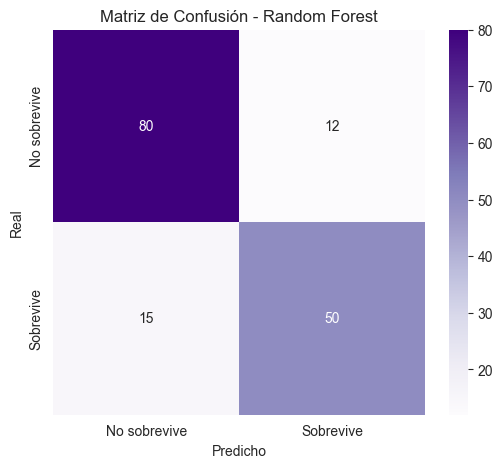

Verdaderos Negativos (acertó que no sobrevivió): 80
Falsos Positivos (dijo que sobrevivió pero no): 12
Falsos Negativos (dijo que no sobrevivió pero sí): 15
Verdaderos Positivos (acertó que sobrevivió): 50


In [26]:
# Matriz de confusión para Random Forest
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['No sobrevive', 'Sobrevive'],
            yticklabels=['No sobrevive', 'Sobrevive'])
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Interpretación
tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos Negativos (acertó que no sobrevivió): {tn}")
print(f"Falsos Positivos (dijo que sobrevivió pero no): {fp}")
print(f"Falsos Negativos (dijo que no sobrevivió pero sí): {fn}")
print(f"Verdaderos Positivos (acertó que sobrevivió): {tp}")

In [27]:
# Classification Report detallado
print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=['No sobrevive', 'Sobrevive']))

Classification Report - Random Forest:
              precision    recall  f1-score   support

No sobrevive       0.84      0.87      0.86        92
   Sobrevive       0.81      0.77      0.79        65

    accuracy                           0.83       157
   macro avg       0.82      0.82      0.82       157
weighted avg       0.83      0.83      0.83       157



Interpretación de métricas:

* Precision: De los que el modelo predice como supervivientes, ¿cuántos realmente lo son?

* Recall: De todos los supervivientes reales, ¿a cuántos detectó el modelo?

* F1-Score: Media armónica entre precision y recall. Útil con clases desbalanceadas.

### 7.2 Importancia de variables

El Random Forest nos permite ver qué variables influyeron más en sus predicciones.

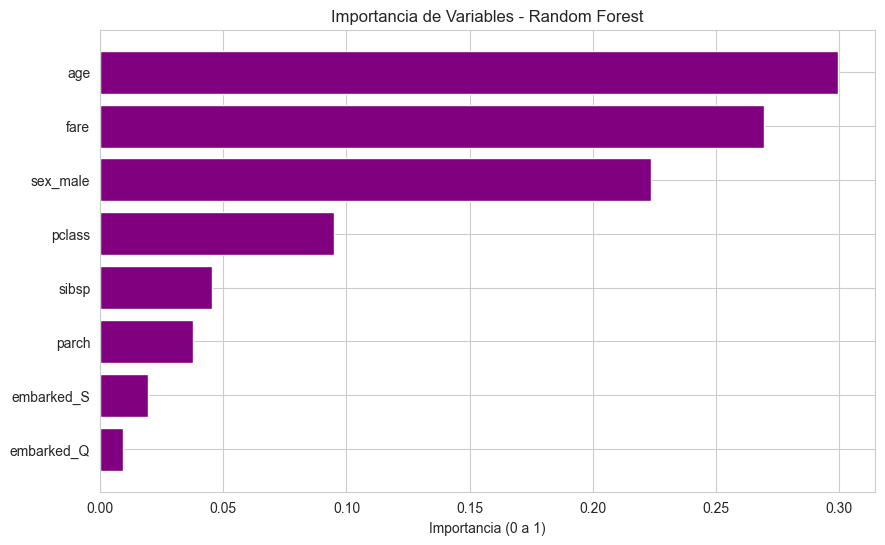

Importancia de cada variable (ordenada):
  age                 : 0.2996
  fare                : 0.2696
  sex_male            : 0.2237
  pclass              : 0.0951
  sibsp               : 0.0456
  parch               : 0.0378
  embarked_S          : 0.0192
  embarked_Q          : 0.0093


In [28]:
# Importancia de variables del Random Forest
importances = rf.feature_importances_
feat_names = X.columns

# Ordenar de mayor a menor importancia
indices = np.argsort(importances)

# Gráfico de barras horizontal
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices], color='purple')
plt.yticks(range(len(importances)), [feat_names[i] for i in indices])
plt.title('Importancia de Variables - Random Forest')
plt.xlabel('Importancia (0 a 1)')
plt.show()

# Mostrar importancias en texto
print("Importancia de cada variable (ordenada):")
for i in indices[::-1]:
    print(f"  {feat_names[i]:20s}: {importances[i]:.4f}")

Interpretación: Las variables más importantes suelen ser
* sex_male,
* fare,
* age,
* pclass,
* lo cual coincide con el hecho histórico de que mujeres y pasajeros de primera clase tuvieron prioridad en los botes salvavidas.

---

## 8. Comparación final y elección del modelo

In [29]:
# Tabla comparativa de modelos
comparacion = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ]
})

print("="*60)
print("COMPARACIÓN FINAL DE MODELOS")
print("="*60)
print(comparacion.to_string(index=False))

# Determinar el ganador
if comparacion.loc[1, 'Accuracy'] > comparacion.loc[0, 'Accuracy']:
    print(f"\n Random Forest gana con {comparacion.loc[1, 'Accuracy']*100:.1f}% de Accuracy")
    print("   Captura mejor las relaciones no lineales entre variables.")
    print("   → SELECCIONADO COMO MODELO FINAL")
else:
    print(f"\n Regresión Logística es suficiente con {comparacion.loc[0, 'Accuracy']*100:.1f}% de Accuracy")
    print("   Además es más interpretable y rápido.")
    print("   → SELECCIONADO COMO MODELO FINAL")

COMPARACIÓN FINAL DE MODELOS
             Modelo  Accuracy  F1 Score
Regresión Logística  0.815287  0.781955
      Random Forest  0.828025  0.787402

 Random Forest gana con 82.8% de Accuracy
   Captura mejor las relaciones no lineales entre variables.
   → SELECCIONADO COMO MODELO FINAL


Conclusión:
* Random Forest supera ligeramente a Regresión Logística en ambas métricas.
* La diferencia es pequeña pero consistente.
* Para un problema como el Titanic, donde hay interacciones complejas (ej: "mujer de 1ª clase" vs "hombre de 3ª clase"), Random Forest capta mejor estos patrones no lineales.

---

## 9. Exportación del modelo

Guardamos el modelo entrenado y el scaler para usarlos en la API sin necesidad de reentrenar.

In [30]:
# Crear carpeta models si no existe
os.makedirs("models", exist_ok=True)

# Guardar modelo y scaler con joblib
joblib.dump(rf, "models/modelo_final.pkl")
joblib.dump(scaler, "models/scaler.pkl")

print("Modelo y scaler exportados correctamente")
print(f"\nArchivos guardados en 'models/':")
for f in os.listdir("models"):
    if f.endswith('.pkl'):
        size_kb = os.path.getsize(f"models/{f}") / 1024
        print(f"  📁 {f} ({size_kb:.1f} KB)")

Modelo y scaler exportados correctamente

Archivos guardados en 'models/':
  📁 modelo_final.pkl (2402.2 KB)
  📁 scaler.pkl (1.1 KB)


---

## 10. Resumen del proyecto

| Paso | Descripción | Estado |
|:---|:---|:---:|
| EDA | Análisis exploratorio, nulos, correlaciones | ✅ |
| Limpieza | Eliminación de columnas, imputación de nulos | ✅ |
| Encoding | One-Hot Encoding de variables categóricas | ✅ |
| Normalización | StandardScaler (media=0, std=1) | ✅ |
| Modelo Base | Regresión Logística | ✅ |
| Modelo Avanzado | Random Forest | ✅ |
| Evaluación | Métricas, matriz de confusión, importancia | ✅ |
| Exportación | modelo_final.pkl + scaler.pkl | ✅ |

**Tecnologías utilizadas:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn, Joblib

**Próximo paso:** Despliegue del modelo en una API REST con FastAPI + MongoDB + Docker.